<a href="https://colab.research.google.com/github/dctorti-lab/Torti_PHYS471_Lab_3/blob/main/Lab_3_e_over_m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here we wish to perform a sanity check on an idea that we discussed in class. By processing an image as an array, we can locate the bright peaks associated with a particular band of colors or intensities and convert their pixelated positions to a distance scale. By doing this, one could calculate the requisite value of voltage, current, or even just the edges of the radii to use in the calculation of the charge to mass ratio. This sample code was provided to us by Professor Hedberg, which was then altered to process the image that I took during the $e/m$ experiment for V = 200 Volts, I = 1 Ampere.

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
im = Image.open("/content/drive/MyDrive/Lab_3/e_over_m.jpg")

We can display the size of the image so that later, when we wish to gauge a row to choose that approximates a straight line through the Lorentz apparatus, we have the y scale available to us.

In [3]:
print(im.format, im.size, im.mode)

JPEG (3024, 4032) RGB


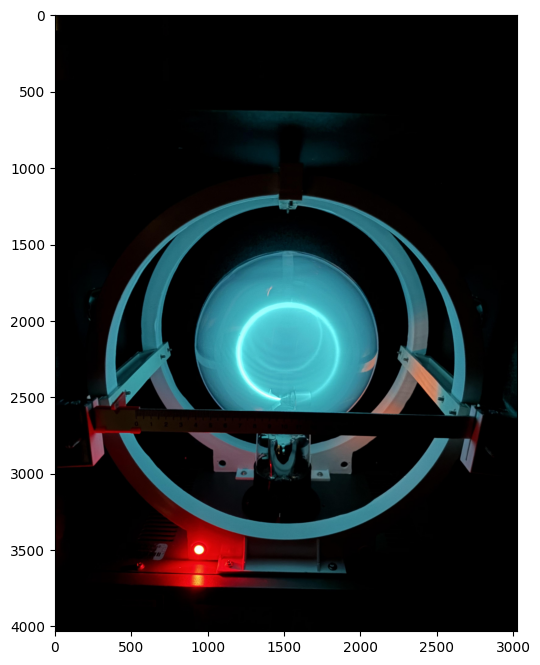

In [4]:
plt.figure(figsize=(6, 8))
imgplot = plt.imshow(im)

Now, having been provided with a listing of the image size, let us choose the 2000th row, such that this particular row approximates a line through the center of the circle from the cathode ray.

In [5]:
imdata = np.array(im, dtype=int)

In [25]:
imdataROW = imdata[2200,:][:,2]
imdatax = np.linspace(start=0, stop=im.size[0],num=im.size[0])

Now, taking the intensity to be associated with the color of blue, let us show a plot of the associated peaks for the distribution of blues throughout our image

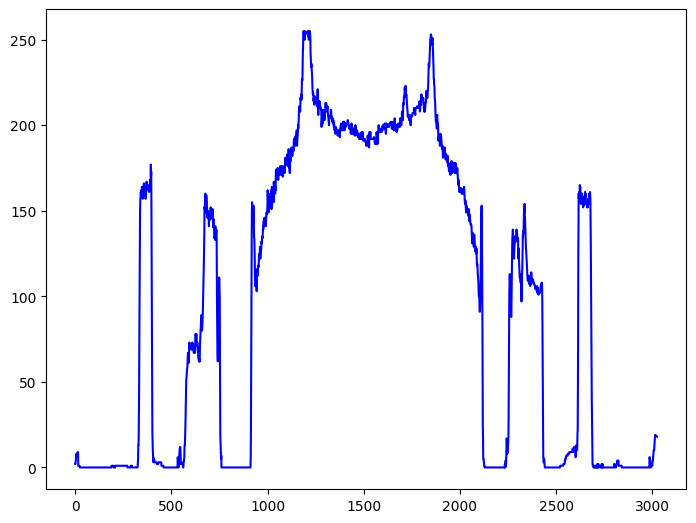

In [26]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
# Plot and show our data
ax.plot(imdatax,imdataROW, color='b', label='Blue')
plt.show()

Taking the code from my writeup from Lab 4: Fast Fourier Transform from PHYS 371, Advanced Lab 1, we can locate the particular peaks that we are interested in. Noting that the two largest peaks occur above an intensity reading of 250, we choose some height that minimizes any stray peaks that we are not interested in.

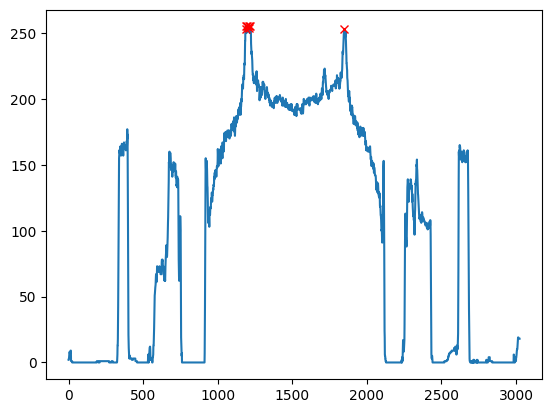

In [39]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(imdataROW, height=253)

plt.plot(imdatax, imdataROW)
plt.plot(imdatax[peaks], imdataROW[peaks], "x", color = 'red')
plt.show()



We could try and superimpose the line plot from above on top of the original image that we uploaded. **As I mention in my lab report, I forgot what the prompt would be for matplotlib to plot a sub image over our primary image. I wrote this question as a prompt for ChatGPT and this is the result I was provided with:**

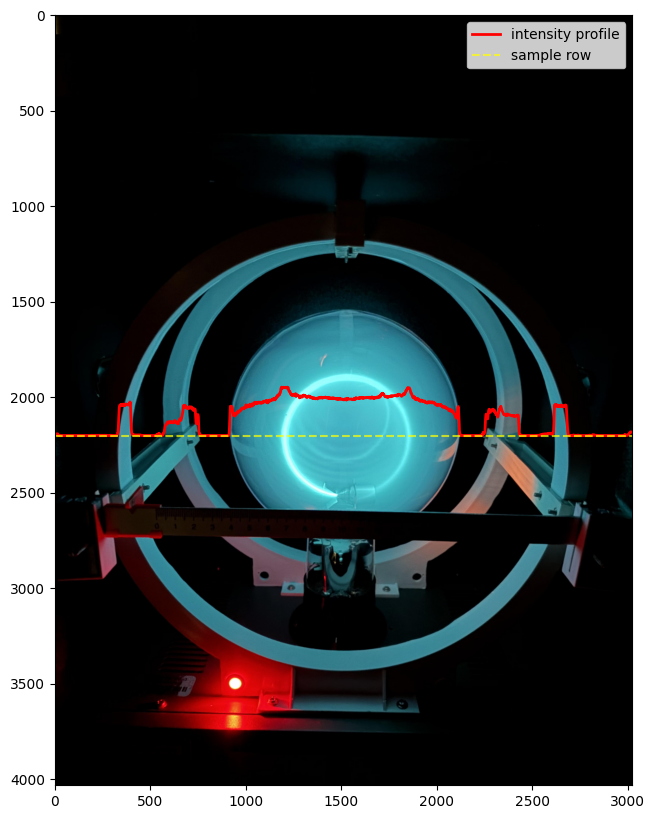

In [41]:
row = 2200
profile = imdataROW   # or your smoothed profile
x = np.arange(len(profile))

# choose where to place the overlaid curve
y_base = row                    # vertical reference level on image
scale = 253 / profile.max()     # controls displayed height of the curve

# image y increases downward, so subtract to make peaks go upward
y_curve = y_base - profile * scale

plt.figure(figsize=(8,10))
plt.imshow(imdata)
plt.plot(x, y_curve, color='red', linewidth=2, label='intensity profile')
plt.axhline(row, color='yellow', linestyle='--', alpha=0.7, label='sample row')
plt.legend()
plt.show()